In [24]:
import requests
import pandas as pd
import time

HEADERS = {"Accept": "application/vnd.github+json"}
BASE    = "https://api.github.com"

def search_repos(query, per_page=100, pages=2):
    repos = []
    for page in range(1, pages + 1):
        try:
            r = requests.get(f"{BASE}/search/repositories",
                params={"q": query, "sort": "stars",
                        "order": "desc", "per_page": per_page, "page": page},
                headers=HEADERS)
            items = r.json().get("items", [])
            if not items:
                break
            repos.extend(items)
            time.sleep(2)
        except Exception as e:
            print(f"Error: {e}")
            break
    return repos

def parse(repos):
    rows = []
    for r in repos:
        rows.append({
            "name":        r["full_name"],
            "stars":       r["stargazers_count"],
            "forks":       r["forks_count"],
            "issues":      r["open_issues_count"],
            "language":    r["language"] or "Unknown",
            "topics":      ", ".join(r.get("topics", [])),
            "size_kb":     r["size"],
            "created_at":  r["created_at"],
            "updated_at":  r["updated_at"],
            "description": (r["description"] or "")[:100],
        })
    return pd.DataFrame(rows)

# fetch many different queries
all_repos = []
queries = [
    "stars:>10 language:python",
    "stars:>10 language:javascript",
    "stars:>10 language:java",
    "stars:>10 language:go",
    "stars:>10 language:rust",
    "stars:>10 language:cpp",
    "stars:>10 language:typescript",
    "stars:>10 language:kotlin",
]

for q in queries:
    repos = search_repos(q, per_page=100, pages=5)
    all_repos.extend(repos)
    print(f"✓ {q} → {len(repos)} repos")
    time.sleep(3)

df = parse(all_repos)
df = df.drop_duplicates("name").reset_index(drop=True)
df.to_csv("github_repos.csv", index=False)
print(f"\n✓ Total: {len(df)} repos saved")

✓ stars:>10 language:python → 500 repos
✓ stars:>10 language:javascript → 500 repos
✓ stars:>10 language:java → 500 repos
✓ stars:>10 language:go → 500 repos
✓ stars:>10 language:rust → 500 repos
✓ stars:>10 language:cpp → 500 repos
✓ stars:>10 language:typescript → 500 repos
✓ stars:>10 language:kotlin → 500 repos

✓ Total: 4000 repos saved


In [25]:
import pandas as pd
df = pd.read_csv("github_repos.csv")

In [26]:
df.head()

,name,stars,forks,issues,language,topics,size_kb,created_at,updated_at,description
0,public-apis/public-apis,439007,48115,1388,Python,"api, apis, dataset, development, free, list, l...",5340,2016-03-20T23:49:42Z,2026-06-03T11:05:04Z,A collective list of free APIs
1,EbookFoundation/free-programming-books,389573,66404,85,Python,"books, education, hacktoberfest, list, resource",21295,2013-10-11T06:50:37Z,2026-06-03T11:06:39Z,:books: Freely available programming books
2,donnemartin/system-design-primer,351554,56559,549,Python,"design, design-patterns, design-system, develo...",11277,2017-02-26T16:15:28Z,2026-06-03T10:46:09Z,Learn how to design large-scale systems. Prep ...
3,vinta/awesome-python,301024,28034,22,Python,"awesome, collections, python, python-framework...",5662,2014-06-27T21:00:06Z,2026-06-03T11:06:04Z,"An opinionated list of Python frameworks, libr..."
4,TheAlgorithms/Python,221610,50705,936,Python,"algorithm, algorithm-competitions, algorithms-...",16472,2016-07-16T09:44:01Z,2026-06-03T10:58:54Z,All Algorithms implemented in Python


In [14]:
df.tail()

,name,stars,forks,issues,watchers,language,topics,size_kb,created_at,updated_at,description,url
741,mailru/FileAPI,3556,450,50,3556,JavaScript,NaN,75288,2012-01-17T06:47:39Z,2026-05-28T12:37:06Z,FileAPI — a set of javascript tools for worki...,https://github.com/mailru/FileAPI
742,Mathieu2301/TradingView-API,3503,700,98,3503,JavaScript,"backtesting, backtesting-trading-strategies, b...",276,2021-03-05T22:24:02Z,2026-06-03T09:51:10Z,📈 Get real-time stocks from TradingView,https://github.com/Mathieu2301/TradingView-API
743,meetDeveloper/freeDictionaryAPI,3499,337,104,3499,JavaScript,"api, dictionary-api, dictonary, free-api, goog...",2505,2018-05-12T08:39:04Z,2026-06-02T19:47:31Z,There was no free Dictionary API on the web wh...,https://github.com/meetDeveloper/freeDictionar...
744,archived-aft-bogus-german-visa-rejectio/insomnium,3482,245,53,3482,JavaScript,"api-client, electron, insomnia, privacy-preser...",17026,2023-09-29T13:29:41Z,2026-06-02T17:33:39Z,Insomnium is a fast local API testing tool tha...,https://github.com/archived-aft-bogus-german-v...
745,hafrey1/LunaTV-config,3481,1347,1,3481,JavaScript,NaN,4691,2025-06-05T12:19:17Z,2026-06-03T09:33:19Z,MoonTV/LunaTV源配置，每日自动检测API状态，可在CF部署CORSAPI中转被墙...,https://github.com/hafrey1/LunaTV-config


In [27]:
df.describe()

,stars,forks,issues,size_kb
count,4000.000000,4000.000000,4000.00000,4.000000e+03
mean,22225.840250,3264.118250,403.29225,2.467493e+05
std,27158.333826,5812.345784,1101.24402,1.460216e+06
min,1790.000000,17.000000,0.00000,3.300000e+01
25%,8414.250000,793.000000,44.00000,7.600750e+03
50%,15697.500000,1735.500000,144.00000,3.434750e+04
75%,25945.250000,3421.500000,392.00000,1.374102e+05
max,445943.000000,109980.000000,33197.00000,6.389486e+07


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   name         4000 non-null   str  
 1   stars        4000 non-null   int64
 2   forks        4000 non-null   int64
 3   issues       4000 non-null   int64
 4   language     4000 non-null   str  
 5   topics       3262 non-null   str  
 6   size_kb      4000 non-null   int64
 7   created_at   4000 non-null   str  
 8   updated_at   4000 non-null   str  
 9   description  3973 non-null   str  
dtypes: int64(4), str(6)
memory usage: 1.1 MB


In [29]:

df["forks"]   = df["forks"].fillna(df["forks"].mean())
df["issues"]  = df["issues"].fillna(df["issues"].mean())
df["size_kb"] = df["size_kb"].fillna(df["size_kb"].mean())
df["stars"]   = df["stars"].fillna(df["stars"].mean())

df["language"]    = df["language"].fillna("Unknown")
df["topics"]      = df["topics"].fillna("")
df["description"] = df["description"].fillna("No description")

df["created_at"] = df["created_at"].fillna(pd.Timestamp.now(tz="UTC"))
df["updated_at"] = df["updated_at"].fillna(pd.Timestamp.now(tz="UTC"))

print("Null values after filling:")
print(df.isnull().sum())

Null values after filling:
name           0
stars          0
forks          0
issues         0
language       0
topics         0
size_kb        0
created_at     0
updated_at     0
description    0
dtype: int64


In [30]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3995    False
3996    False
3997    False
3998    False
3999    False
Length: 4000, dtype: bool

In [31]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pickle

# load
df = pd.read_csv("github_repos.csv")

# fill nulls
df["forks"]       = df["forks"].fillna(df["forks"].mean())
df["issues"]      = df["issues"].fillna(df["issues"].mean())
df["size_kb"]     = df["size_kb"].fillna(df["size_kb"].mean())
df["language"]    = df["language"].fillna("Unknown")
df["topics"]      = df["topics"].fillna("")
df["description"] = df["description"].fillna("")

# encode
df["language_enc"] = LabelEncoder().fit_transform(df["language"])

# target
df["is_popular"] = (df["stars"] > df["stars"].median()).astype(int)

# features
X = df[["forks", "issues", "size_kb", "language_enc"]]
y = df["is_popular"]

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# train
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# result
print(f"Accuracy: {accuracy_score(y_test, model.predict(X_test))*100:.1f}%")

# save
pickle.dump(model,  open("model.pkl",  "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
print("✓ model.pkl saved")
print("✓ scaler.pkl saved")

Accuracy: 81.0%
✓ model.pkl saved
✓ scaler.pkl saved


In [32]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import pickle

df = pd.read_csv("github_repos.csv")

df["forks"]       = df["forks"].fillna(df["forks"].mean())
df["issues"]      = df["issues"].fillna(df["issues"].mean())
df["size_kb"]     = df["size_kb"].fillna(df["size_kb"].mean())
df["language"]    = df["language"].fillna("Unknown")
df["topics"]      = df["topics"].fillna("")
df["description"] = df["description"].fillna("")

def count_topics(x):
    if x == "":
        return 0
    return len(x.split(","))

def desc_length(x):
    return len(x)

df["language_enc"]    = LabelEncoder().fit_transform(df["language"])
df["topics_count"]    = df["topics"].apply(count_topics)
df["description_len"] = df["description"].apply(desc_length)
df["created_at"]      = pd.to_datetime(df["created_at"], utc=True)
df["updated_at"]      = pd.to_datetime(df["updated_at"], utc=True)
now                   = pd.Timestamp.now(tz="UTC")
df["age_days"]        = (now - df["created_at"]).dt.days
df["days_since_update"] = (now - df["updated_at"]).dt.days

df["is_popular"] = (df["stars"] > df["stars"].median()).astype(int)

X = df[["forks", "issues", "size_kb", "language_enc",
        "topics_count", "description_len",
        "age_days", "days_since_update"]]
y = df["is_popular"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42)
model.fit(X_train, y_train)

print(f"Accuracy: {accuracy_score(y_test, model.predict(X_test))*100:.1f}%")


pickle.dump(model, open("model.pkl", "wb"))
print("✓ model.pkl saved")

Accuracy: 86.4%
✓ model.pkl saved


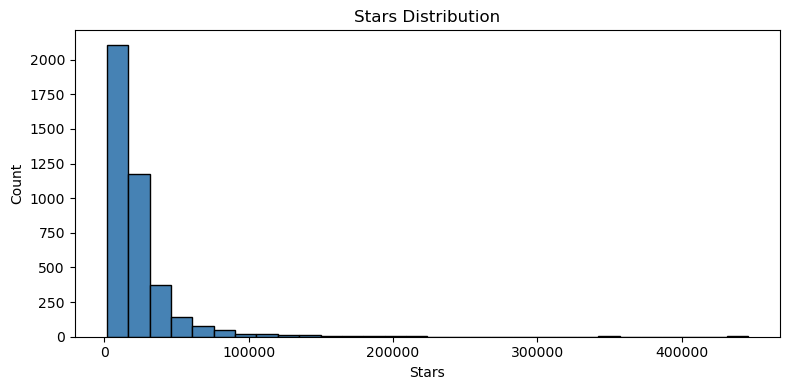

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── 1. Stars Distribution ──────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(df["stars"], bins=30, color="steelblue", edgecolor="black")
plt.title("Stars Distribution")
plt.xlabel("Stars")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("stars_dist.png")
plt.show()

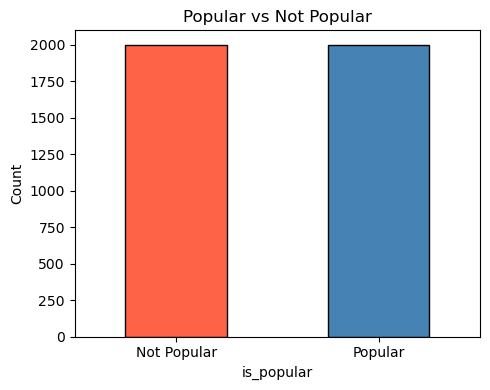

In [34]:
plt.figure(figsize=(5, 4))
df["is_popular"].value_counts().plot(kind="bar",
    color=["tomato","steelblue"], edgecolor="black")
plt.xticks([0, 1], ["Not Popular", "Popular"], rotation=0)
plt.title("Popular vs Not Popular")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("popular_count.png")
plt.show()


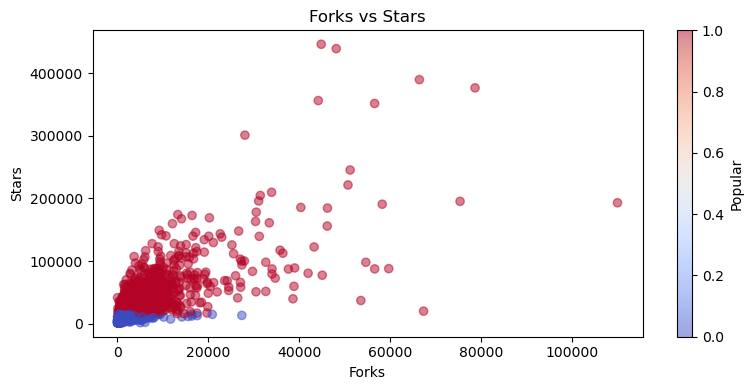

In [35]:
plt.figure(figsize=(8, 4))
plt.scatter(df["forks"], df["stars"],
            c=df["is_popular"], cmap="coolwarm", alpha=0.5)
plt.title("Forks vs Stars")
plt.xlabel("Forks")
plt.ylabel("Stars")
plt.colorbar(label="Popular")
plt.tight_layout()
plt.savefig("forks_vs_stars.png")
plt.show()

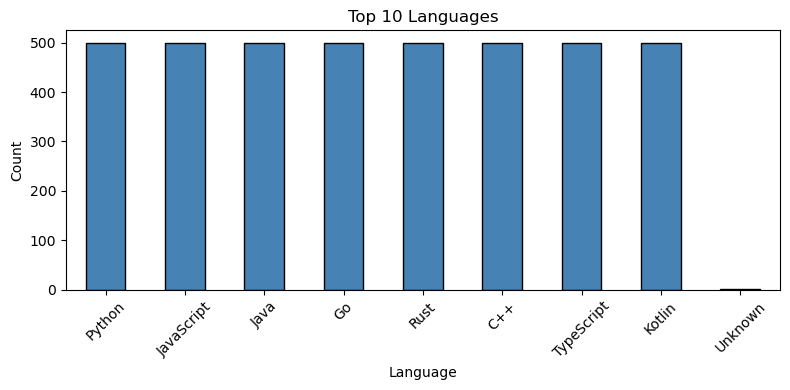

In [36]:
plt.figure(figsize=(8, 4))
df["language"].value_counts().head(10).plot(
    kind="bar", color="steelblue", edgecolor="black")
plt.title("Top 10 Languages")
plt.xlabel("Language")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top_languages.png")
plt.show()

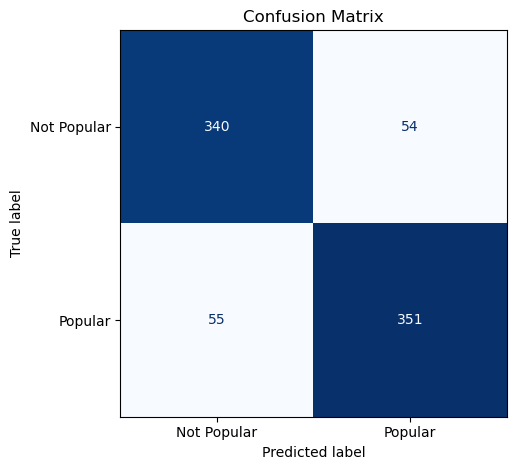

In [37]:
cm = confusion_matrix(y_test, model.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=["Not Popular","Popular"]).plot(
    colorbar=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()


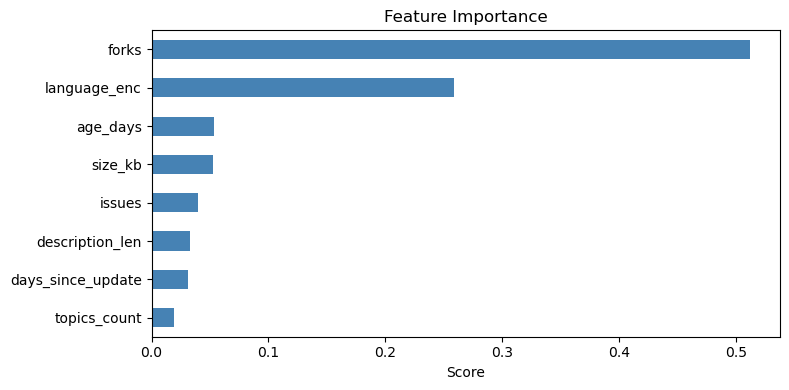

In [39]:
importance = pd.Series(model.feature_importances_,
                       index=["forks","issues","size_kb","language_enc",
                              "topics_count","description_len",
                              "age_days","days_since_update"])
plt.figure(figsize=(8, 4))
importance.sort_values().plot(kind="barh", color="steelblue")
plt.title("Feature Importance")
plt.xlabel("Score")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()
